<a href="https://colab.research.google.com/github/RanjithJC/Tech-Atelier/blob/main/FORCEFLOW_AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn xgboost shap matplotlib

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("final_dataset.csv")

# Show dataset information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (24831, 31)

Column Names:
['personnel_id', 'week', 'duty_hours', 'consecutive_duty_days', 'overtime_hours', 'workload_score', 'sleep_hours', 'fatigue_score', 'stress_score', 'mood_score', 'emotional_exhaustion', 'attendance_score', 'activity_level', 'performance_score', 'social_withdrawal', 'behavioral_change', 'age', 'service_years', 'rank_level', 'transfer_frequency', 'training_hours', 'deployment_days', 'deployment_frequency', 'operational_exposure', 'leave_days', 'days_since_last_leave', 'leave_frequency', 'stress_risk_score', 'stress_risk', 'burnout_risk_score', 'burnout_risk']

First 5 Rows:


,personnel_id,week,duty_hours,consecutive_duty_days,overtime_hours,workload_score,sleep_hours,fatigue_score,stress_score,mood_score,...,deployment_days,deployment_frequency,operational_exposure,leave_days,days_since_last_leave,leave_frequency,stress_risk_score,stress_risk,burnout_risk_score,burnout_risk
0,P0001,1,63,7,18,4.5,6.1,5.6,5.4,6.1,...,77,1,1,1,10,1,48.9,Moderate,46.7,Moderate
1,P0001,2,58,11,13,4.3,6.5,3.3,5.3,6.7,...,77,1,1,1,10,1,45.8,Moderate,44.6,Moderate
2,P0001,3,39,14,0,1.1,7.0,3.8,4.0,8.2,...,77,1,1,1,10,1,34.1,Moderate,34.4,Moderate
3,P0001,4,37,9,0,3.0,7.8,2.0,3.8,7.3,...,77,1,1,1,10,1,30.6,Moderate,30.7,Moderate
4,P0001,5,43,4,0,3.3,7.7,3.6,2.2,6.6,...,77,1,1,1,10,1,25.9,Low,34.8,Moderate



Missing Values:
personnel_id             0
week                     0
duty_hours               0
consecutive_duty_days    0
overtime_hours           0
workload_score           0
sleep_hours              0
fatigue_score            0
stress_score             0
mood_score               0
emotional_exhaustion     0
attendance_score         0
activity_level           0
performance_score        0
social_withdrawal        0
behavioral_change        0
age                      0
service_years            0
rank_level               0
transfer_frequency       0
training_hours           0
deployment_days          0
deployment_frequency     0
operational_exposure     0
leave_days               0
days_since_last_leave    0
leave_frequency          0
stress_risk_score        0
stress_risk              1
burnout_risk_score       1
burnout_risk             1
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Target column
target = "burnout_risk"

# Remove columns that should not be used as input
X = df.drop(columns=["personnel_id",
                     "burnout_risk",
                     "burnout_risk_score",
                     "stress_risk",
                     "stress_risk_score"])

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["rank_level"] = le.fit_transform(X["rank_level"].astype(str))

# Target
y = df[target]

# Convert target labels into numbers
le = LabelEncoder()
y = le.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train XGBoost model
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Report
print(classification_report(y_test, y_pred))

Accuracy: 0.9331588483994363
              precision    recall  f1-score   support

           1       0.75      0.51      0.61       197
           2       0.82      0.67      0.74       420
           3       0.95      0.98      0.96      4349
           4       0.00      0.00      0.00         1

    accuracy                           0.93      4967
   macro avg       0.63      0.54      0.58      4967
weighted avg       0.93      0.93      0.93      4967



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert all text columns to numbers
le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col].astype(str))

In [ ]:
import numpy as np
import pandas as pd

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget classes and counts:")

classes, counts = np.unique(y, return_counts=True)

for c, count in zip(classes, counts):
    print(c, ":", count)

print("\nInput columns:")
print(X.columns.tolist())

X shape: (24831, 26)
y shape: (24831,)

Target classes and counts:
0 : 1
1 : 934
2 : 2097
3 : 21798
4 : 1

Input columns:
['week', 'duty_hours', 'consecutive_duty_days', 'overtime_hours', 'workload_score', 'sleep_hours', 'fatigue_score', 'stress_score', 'mood_score', 'emotional_exhaustion', 'attendance_score', 'activity_level', 'performance_score', 'social_withdrawal', 'behavioral_change', 'age', 'service_years', 'rank_level', 'transfer_frequency', 'training_hours', 'deployment_days', 'deployment_frequency', 'operational_exposure', 'leave_days', 'days_since_last_leave', 'leave_frequency']


In [ ]:
print("Available columns:")
print(df.columns.tolist())

Available columns:
['personnel_id', 'week', 'duty_hours', 'consecutive_duty_days', 'overtime_hours', 'workload_score', 'sleep_hours', 'fatigue_score', 'stress_score', 'mood_score', 'emotional_exhaustion', 'attendance_score', 'activity_level', 'performance_score', 'social_withdrawal', 'behavioral_change', 'age', 'service_years', 'rank_level', 'transfer_frequency', 'training_hours', 'deployment_days', 'deployment_frequency', 'operational_exposure', 'leave_days', 'days_since_last_leave', 'leave_frequency', 'stress_risk_score', 'stress_risk', 'burnout_risk_score', 'burnout_risk']


In [ ]:
# Find possible target columns

print("Possible target columns:")

for col in df.columns:
    if any(word in col.lower() for word in ["risk", "burnout", "stress", "target", "label"]):
        print("-", col)

Possible target columns:
- stress_score
- stress_risk_score
- stress_risk
- burnout_risk_score
- burnout_risk


In [ ]:
print("\nDataset columns with data types:\n")

for col in df.columns:
    print(col, "→", df[col].dtype)


Dataset columns with data types:

personnel_id → object
week → int64
duty_hours → int64
consecutive_duty_days → int64
overtime_hours → int64
workload_score → float64
sleep_hours → float64
fatigue_score → float64
stress_score → float64
mood_score → float64
emotional_exhaustion → float64
attendance_score → float64
activity_level → float64
performance_score → float64
social_withdrawal → float64
behavioral_change → float64
age → int64
service_years → int64
rank_level → object
transfer_frequency → int64
training_hours → float64
deployment_days → int64
deployment_frequency → int64
operational_exposure → int64
leave_days → int64
days_since_last_leave → int64
leave_frequency → int64
stress_risk_score → float64
stress_risk → object
burnout_risk_score → float64
burnout_risk → object


In [ ]:
print("TARGET / RISK COLUMNS")
print("=" * 40)

for col in df.columns:
    if any(word in col.lower() for word in ["risk", "burnout", "stress", "label", "target"]):
        print("\nColumn:", col)
        print("Type:", df[col].dtype)
        print("Values:")
        print(df[col].value_counts(dropna=False).sort_index())

TARGET / RISK COLUMNS

Column: stress_score
Type: float64
Values:
stress_score
1.0     406
1.1      51
1.2      59
1.3      60
1.4      90
       ... 
9.6      19
9.7      16
9.8      13
9.9      11
10.0     71
Name: count, Length: 91, dtype: int64

Column: stress_risk_score
Type: float64
Values:
stress_risk_score
9.5     1
10.1    1
12.2    1
12.3    2
12.5    1
       ..
75.0    1
75.1    1
76.7    1
77.9    1
78.0    1
Name: count, Length: 562, dtype: int64

Column: stress_risk
Type: object
Values:
stress_risk
Critical        5
High         2264
Low          2004
Moderate    20557
NaN             1
Name: count, dtype: int64

Column: burnout_risk_score
Type: float64
Values:
burnout_risk_score
8.1     1
11.1    1
11.5    1
11.6    1
11.8    1
       ..
77.9    1
78.1    1
78.7    1
80.1    1
NaN     1
Name: count, Length: 586, dtype: int64

Column: burnout_risk
Type: object
Values:
burnout_risk
Critical        1
High          934
Low          2097
Moderate    21798
NaN             1
N

In [ ]:
# FORCEFLOW AI - FIXED ML TRAINING

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# 1. Prepare data
X_model = X_model.copy()

X_model = X_model.replace([np.inf, -np.inf], np.nan)
X_model = X_model.fillna(0)

# 2. Convert target classes to 0, 1, 2
unique_classes = sorted(np.unique(y_model))

class_map = {
    old: new for new, old in enumerate(unique_classes)
}

y_encoded = np.array([
    class_map[value] for value in y_model
])

print("Class mapping:", class_map)

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# 4. Create XGBoost model
model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(unique_classes),
    eval_metric="mlogloss",
    random_state=42
)

# 5. TRAIN MODEL
print("\nTraining FORCEFLOW AI...")
model.fit(X_train, y_train)

print("✅ MODEL TRAINING COMPLETED!")

# 6. Prediction
y_pred = model.predict(X_test)

# 7. Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("FORCEFLOW AI RESULT")
print("==============================")

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Class mapping: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2}
Training data: (19863, 26)
Testing data: (4966, 26)

Training FORCEFLOW AI...
✅ MODEL TRAINING COMPLETED!

FORCEFLOW AI RESULT
Accuracy: 93.27 %

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.50      0.62       187
           1       0.81      0.62      0.70       419
           2       0.94      0.98      0.96      4360

    accuracy                           0.93      4966
   macro avg       0.86      0.70      0.76      4966
weighted avg       0.93      0.93      0.93      4966


Confusion Matrix:
[[  94    0   93]
 [   0  259  160]
 [  21   60 4279]]


Creating AI explanation...
✅ SHAP explanation created!


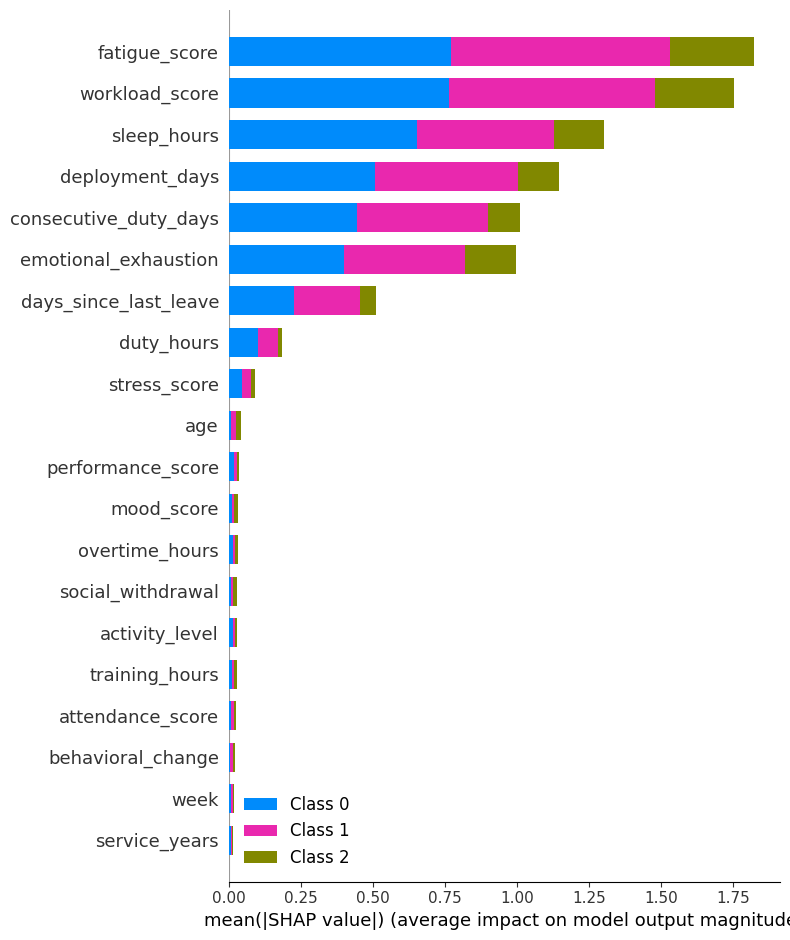

In [ ]:
# FORCEFLOW AI - Explainable AI

import shap
import matplotlib.pyplot as plt

print("Creating AI explanation...")

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

print("✅ SHAP explanation created!")

# Feature importance
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [ ]:
# ==========================================
# SMART RISK PREDICTION
# ==========================================

import pandas as pd
import numpy as np

# Predict test data
y_pred = model.predict(X_test)

# Convert everything safely to 1-D arrays
actual = np.asarray(y_test).ravel()
predicted = np.asarray(y_pred).ravel()

# Convert prediction to risk level
def risk_level(pred):
    pred = int(pred)

    if pred == 0:
        return "LOW"
    elif pred == 1:
        return "MEDIUM"
    elif pred == 2:
        return "HIGH"
    else:
        return "CRITICAL"

risk = [risk_level(p) for p in predicted]

# Create result table
results = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted,
    "Risk_Level": risk
})

print("SMART RISK PREDICTION")
print("=====================")
print(results.head(20))

print("\nRISK DISTRIBUTION")
print("=================")
print(results["Risk_Level"].value_counts())

SMART RISK PREDICTION
    Actual  Predicted Risk_Level
0        1          1     MEDIUM
1        2          2       HIGH
2        2          2       HIGH
3        2          2       HIGH
4        2          2       HIGH
5        2          2       HIGH
6        2          1     MEDIUM
7        2          2       HIGH
8        2          2       HIGH
9        0          0        LOW
10       2          2       HIGH
11       2          2       HIGH
12       2          2       HIGH
13       2          2       HIGH
14       2          2       HIGH
15       0          2       HIGH
16       2          2       HIGH
17       2          2       HIGH
18       2          2       HIGH
19       2          2       HIGH

RISK DISTRIBUTION
Risk_Level
HIGH      4532
MEDIUM     319
LOW        115
Name: count, dtype: int64


In [ ]:
# ==========================================
# SMART RECOMMENDATION ENGINE
# ==========================================

def get_recommendation(row):
    risk = row["Risk_Level"]

    if risk == "LOW":
        return "Normal monitoring. Maintain current workload and wellness."

    elif risk == "MEDIUM":
        return "Monitor workload and fatigue. Consider short rest or wellness support."

    elif risk == "HIGH":
        return "Reduce workload, review duty schedule, and recommend leave/rest."

    elif risk == "CRITICAL":
        return "Immediate HR intervention. Reduce workload and arrange rest/leave."

    else:
        return "Review personnel condition."


# Add recommendations
results["Recommendation"] = results.apply(get_recommendation, axis=1)

# Display smart results
print("SMART PERSONNEL RISK SYSTEM")
print("============================")
print(results.head(20).to_string(index=False))

SMART PERSONNEL RISK SYSTEM
 Actual  Predicted Risk_Level                                                         Recommendation
      1          1     MEDIUM Monitor workload and fatigue. Consider short rest or wellness support.
      2          2       HIGH       Reduce workload, review duty schedule, and recommend leave/rest.
      2          2       HIGH       Reduce workload, review duty schedule, and recommend leave/rest.
      2          2       HIGH       Reduce workload, review duty schedule, and recommend leave/rest.
      2          2       HIGH       Reduce workload, review duty schedule, and recommend leave/rest.
      2          2       HIGH       Reduce workload, review duty schedule, and recommend leave/rest.
      2          1     MEDIUM Monitor workload and fatigue. Consider short rest or wellness support.
      2          2       HIGH       Reduce workload, review duty schedule, and recommend leave/rest.
      2          2       HIGH       Reduce workload, review dut

In [ ]:
# ==========================================
# HR RISK SUMMARY
# ==========================================

summary = results["Risk_Level"].value_counts()

print("HR RISK SUMMARY")
print("===============")

for level in ["LOW", "MEDIUM", "HIGH", "CRITICAL"]:
    print(level, ":", summary.get(level, 0))

HR RISK SUMMARY
LOW : 115
MEDIUM : 319
HIGH : 4532
CRITICAL : 0


In [ ]:
# ==========================================
# FINAL SMART HR RISK DASHBOARD
# ==========================================

# Copy prediction results
dashboard = results.copy()

# Add Personnel ID if available
if "personnel_id" in df.columns:
    try:
        dashboard["personnel_id"] = df.loc[X_test.index, "personnel_id"].values
    except:
        dashboard["personnel_id"] = range(1, len(dashboard) + 1)
else:
    dashboard["personnel_id"] = range(1, len(dashboard) + 1)

# Put Personnel ID first
dashboard = dashboard[
    ["personnel_id", "Actual", "Predicted",
     "Risk_Level", "Recommendation"]
]

print("==========================================")
print("     SMART PERSONNEL WELLNESS SYSTEM")
print("==========================================")

print("\nHIGH / CRITICAL RISK PERSONNEL")
print("==========================================")

high_risk = dashboard[
    dashboard["Risk_Level"].isin(["HIGH", "CRITICAL"])
]

print(high_risk.head(20).to_string(index=False))

     SMART PERSONNEL WELLNESS SYSTEM

HIGH / CRITICAL RISK PERSONNEL
personnel_id  Actual  Predicted Risk_Level                                                   Recommendation
       P0079       2          2       HIGH Reduce workload, review duty schedule, and recommend leave/rest.
       P0761       2          2       HIGH Reduce workload, review duty schedule, and recommend leave/rest.
       P0467       2          2       HIGH Reduce workload, review duty schedule, and recommend leave/rest.
       P0083       2          2       HIGH Reduce workload, review duty schedule, and recommend leave/rest.
       P1775       2          2       HIGH Reduce workload, review duty schedule, and recommend leave/rest.
       P1016       2          2       HIGH Reduce workload, review duty schedule, and recommend leave/rest.
       P0885       2          2       HIGH Reduce workload, review duty schedule, and recommend leave/rest.
       P2056       2          2       HIGH Reduce workload, review 

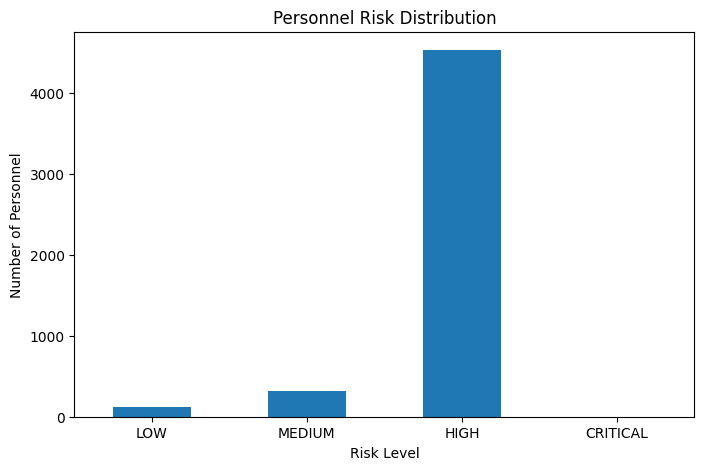

In [ ]:
# ==========================================
# RISK LEVEL DASHBOARD
# ==========================================

import matplotlib.pyplot as plt

risk_counts = dashboard["Risk_Level"].value_counts()

risk_counts = risk_counts.reindex(
    ["LOW", "MEDIUM", "HIGH", "CRITICAL"],
    fill_value=0
)

plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")

plt.title("Personnel Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Personnel")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# ==========================================
# SINGLE PERSON SMART RISK PREDICTION
# ==========================================

def predict_person_risk(person_data):

    # Convert input into DataFrame
    input_data = pd.DataFrame([person_data])

    # Keep exactly the same columns used during training
    input_data = input_data[X.columns]

    # Convert data types safely
    for col in input_data.columns:
        input_data[col] = pd.to_numeric(
            input_data[col], errors="coerce"
        )

    # Fill missing values
    input_data = input_data.fillna(X.median(numeric_only=True))

    # Prediction
    prediction = model.predict(input_data)[0]

    # Risk mapping
    risk_map = {
        0: "LOW",
        1: "MEDIUM",
        2: "HIGH",
        3: "CRITICAL",
        4: "CRITICAL"
    }

    risk = risk_map.get(int(prediction), "UNKNOWN")

    # Recommendation
    if risk == "LOW":
        recommendation = "Continue normal monitoring."
    elif risk == "MEDIUM":
        recommendation = "Monitor workload, fatigue and wellness."
    elif risk == "HIGH":
        recommendation = "Reduce workload and consider rest or leave."
    else:
        recommendation = "Immediate review, rest/leave and HR intervention recommended."

    return risk, recommendation


print("Prediction function created successfully!")

Prediction function created successfully!


In [ ]:
# ==========================================
# TEST PERSON
# ==========================================

sample_person = X.iloc[0].to_dict()

risk, recommendation = predict_person_risk(sample_person)

print("SMART RISK RESULT")
print("=================")
print("Risk Level :", risk)
print("Action     :", recommendation)

SMART RISK RESULT
Risk Level : HIGH
Action     : Reduce workload and consider rest or leave.


In [ ]:
# ==========================================
# FORCEFLOW AI - OVERALL OUTPUT
# ==========================================

import pandas as pd
import numpy as np

# Use the first test person as demo
person_index = X_test.index[0]

# Original parameter values
person = df.loc[person_index]

print("=" * 55)
print("        FORCEFLOW AI - WELFARE ANALYSIS")
print("=" * 55)

# Show actual parameters available in your dataset
parameters = [
    "duty_hours",
    "overtime_hours",
    "workload_score",
    "sleep_hours",
    "fatigue_score",
    "stress_score",
    "mood_score",
    "emotional_exhaustion",
    "deployment_days",
    "consecutive_duty_days",
    "days_since_last_leave",
    "attendance_score",
    "activity_level",
    "performance_score",
    "social_withdrawal",
    "behavioral_change"
]

print("\n📊 PERSONNEL PARAMETERS")
print("-" * 55)

for p in parameters:
    if p in df.columns:
        print(f"{p:28} : {person[p]}")

# ML prediction
prediction = int(model.predict(X_test.iloc[[0]])[0])

# Convert internal model class to human-readable output
risk_map = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
    3: "CRITICAL",
    4: "CRITICAL"
}

risk = risk_map.get(prediction, "UNKNOWN")

print("\n" + "=" * 55)
print("              OVERALL RESULT")
print("=" * 55)

print(f"\n🧠 WELFARE RISK : {risk}")

# Simple explanation based on parameters
print("\n🔎 IMPORTANT PARAMETERS")

if "workload_score" in df.columns:
    if person["workload_score"] >= 70:
        print("⚠ High workload")

if "fatigue_score" in df.columns:
    if person["fatigue_score"] >= 70:
        print("⚠ High fatigue")

if "sleep_hours" in df.columns:
    if person["sleep_hours"] < 6:
        print("⚠ Low sleep duration")

if "stress_score" in df.columns:
    if person["stress_score"] >= 70:
        print("⚠ High stress")

if "emotional_exhaustion" in df.columns:
    if person["emotional_exhaustion"] >= 70:
        print("⚠ High emotional exhaustion")

if "consecutive_duty_days" in df.columns:
    if person["consecutive_duty_days"] >= 14:
        print("⚠ Long consecutive duty period")

if "days_since_last_leave" in df.columns:
    if person["days_since_last_leave"] >= 60:
        print("⚠ Long gap since last leave")

print("\n💡 SYSTEM ROLE")
print("Early welfare-risk identification and")
print("preventive decision support — not medical diagnosis.")

print("\n" + "=" * 55)

        FORCEFLOW AI - WELFARE ANALYSIS

📊 PERSONNEL PARAMETERS
-------------------------------------------------------
duty_hours                   : 52
overtime_hours               : 7
workload_score               : 2.7
sleep_hours                  : 6.1
fatigue_score                : 2.1
stress_score                 : 2.6
mood_score                   : 6.8
emotional_exhaustion         : 1.6
deployment_days              : 6
consecutive_duty_days        : 4
days_since_last_leave        : 9
attendance_score             : 80.6
activity_level               : 69.0
performance_score            : 66.3
social_withdrawal            : 6.4
behavioral_change            : 4.2

              OVERALL RESULT

🧠 WELFARE RISK : MEDIUM

🔎 IMPORTANT PARAMETERS

💡 SYSTEM ROLE
Early welfare-risk identification and
preventive decision support — not medical diagnosis.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/final_dataset.csv')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/final_dataset.csv'

In [ ]:
df = pd.read_csv('/content/final_dataset (1).csv')

In [ ]:
df.head()

,personnel_id,week,duty_hours,consecutive_duty_days,overtime_hours,workload_score,sleep_hours,attendance_score,performance_score,age,...,transfer_frequency,training_hours,deployment_days,deployment_frequency,operational_exposure,leave_days,days_since_last_leave,leave_frequency,stress_risk_score,stress_risk
0,P0001,1,63,7,18,4.5,6.1,78.9,92.1,27,...,2,11.1,77,1,1,1,10,1,48.9,Moderate
1,P0001,2,58,11,13,4.3,6.5,90.4,75.8,27,...,2,11.1,77,1,1,1,10,1,45.8,Moderate
2,P0001,3,39,14,0,1.1,7.0,89.0,81.7,27,...,2,11.1,77,1,1,1,10,1,34.1,Moderate
3,P0001,4,37,9,0,3.0,7.8,97.3,78.0,27,...,2,11.1,77,1,1,1,10,1,30.6,Moderate
4,P0001,5,43,4,0,3.3,7.7,81.4,82.3,27,...,2,11.1,77,1,1,1,10,1,25.9,Low


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (60000, 22)

Columns:
['personnel_id', 'week', 'duty_hours', 'consecutive_duty_days', 'overtime_hours', 'workload_score', 'sleep_hours', 'attendance_score', 'performance_score', 'age', 'service_years', 'rank_level', 'transfer_frequency', 'training_hours', 'deployment_days', 'deployment_frequency', 'operational_exposure', 'leave_days', 'days_since_last_leave', 'leave_frequency', 'stress_risk_score', 'stress_risk']


In [ ]:
print(df.columns.tolist())

['personnel_id', 'week', 'duty_hours', 'consecutive_duty_days', 'overtime_hours', 'workload_score', 'sleep_hours', 'attendance_score', 'performance_score', 'age', 'service_years', 'rank_level', 'transfer_frequency', 'training_hours', 'deployment_days', 'deployment_frequency', 'operational_exposure', 'leave_days', 'days_since_last_leave', 'leave_frequency', 'stress_risk_score', 'stress_risk']


In [ ]:
print("Columns in the new dataset:")
for i, col in enumerate(df.columns, 1):
    print(i, "→", col)

Columns in the new dataset:
1 → personnel_id
2 → week
3 → duty_hours
4 → consecutive_duty_days
5 → overtime_hours
6 → workload_score
7 → sleep_hours
8 → attendance_score
9 → performance_score
10 → age
11 → service_years
12 → rank_level
13 → transfer_frequency
14 → training_hours
15 → deployment_days
16 → deployment_frequency
17 → operational_exposure
18 → leave_days
19 → days_since_last_leave
20 → leave_frequency
21 → stress_risk_score
22 → stress_risk


In [ ]:
print("Stress Risk Values:")
print(df["stress_risk"].value_counts())

print("\nSample data:")
display(df.head())

Stress Risk Values:
stress_risk
Moderate    49389
High         5740
Low          4852
Critical       19
Name: count, dtype: int64

Sample data:


,personnel_id,week,duty_hours,consecutive_duty_days,overtime_hours,workload_score,sleep_hours,attendance_score,performance_score,age,...,transfer_frequency,training_hours,deployment_days,deployment_frequency,operational_exposure,leave_days,days_since_last_leave,leave_frequency,stress_risk_score,stress_risk
0,P0001,1,63,7,18,4.5,6.1,78.9,92.1,27,...,2,11.1,77,1,1,1,10,1,48.9,Moderate
1,P0001,2,58,11,13,4.3,6.5,90.4,75.8,27,...,2,11.1,77,1,1,1,10,1,45.8,Moderate
2,P0001,3,39,14,0,1.1,7.0,89.0,81.7,27,...,2,11.1,77,1,1,1,10,1,34.1,Moderate
3,P0001,4,37,9,0,3.0,7.8,97.3,78.0,27,...,2,11.1,77,1,1,1,10,1,30.6,Moderate
4,P0001,5,43,4,0,3.3,7.7,81.4,82.3,27,...,2,11.1,77,1,1,1,10,1,25.9,Low


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Remove ID and target
X = df.drop(columns=["personnel_id", "stress_risk"])
y = df["stress_risk"]

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create XGBoost model
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

# Train
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("======================================")
print("       XGBOOST MODEL RESULT")
print("======================================")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:rank_level: object

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Copy dataset
data = df.copy()

# Remove ID column
data = data.drop(columns=["personnel_id"])

# Separate target
X = data.drop(columns=["stress_risk"])
y = data["stress_risk"]

# Convert any text/categorical columns into numbers
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Encode target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y.astype(str))

# Check data
print("Features:", X.shape)
print("Target classes:", target_encoder.classes_)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# XGBoost
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Result
accuracy = accuracy_score(y_test, y_pred)

print("\n======================================")
print("        XGBOOST MODEL RESULT")
print("======================================")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_,
    zero_division=0
))

Features: (60000, 20)
Target classes: ['Critical' 'High' 'Low' 'Moderate']

        XGBOOST MODEL RESULT
Accuracy: 99.82%

Classification Report:
              precision    recall  f1-score   support

    Critical       0.00      0.00      0.00         4
        High       0.99      0.99      0.99      1148
         Low       1.00      1.00      1.00       970
    Moderate       1.00      1.00      1.00      9878

    accuracy                           1.00     12000
   macro avg       0.75      0.75      0.75     12000
weighted avg       1.00      1.00      1.00     12000



In [ ]:
import pickle

# Save the trained XGBoost model
with open("forceflow_xgboost_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download("forceflow_xgboost_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>